In [1]:
import os, json, shutil, warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image
import mlflow

warnings.filterwarnings('ignore')

# Paths
BASE       = Path(r'G:\defect_detection')
RAW        = BASE / 'data' / 'raw'
PROC       = BASE / 'data' / 'processed'
AUG        = BASE / 'data' / 'augmented'
STATS_DIR  = BASE / 'data' / 'stats'

for p in [RAW, PROC, AUG, STATS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 4), 'font.size': 11})
sns.set_palette('muted')

print('All imports OK')
print(f'OpenCV version  : {cv2.__version__}')
print(f'Project root    : {BASE}')

All imports OK
OpenCV version  : 4.13.0
Project root    : G:\defect_detection


In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key='')

# Get your workspace name
workspace = rf.workspace()
print(workspace)

loading Roboflow workspace...
{
  "name": "learningml",
  "url": "learningml-nj9tp",
  "projects": []
}


In [6]:
import subprocess
subprocess.run(['pip', 'install', 'kaggle', '-q'], capture_output=True)

# Download directly using requests
import requests
import zipfile
import os

# Use direct URL from GitHub
url = 'https://github.com/abin24/Magnetic-tile-defect-datasets./archive/refs/heads/master.zip'

print('Downloading defect dataset...')
response = requests.get(url, stream=True)
zip_path = str(RAW / 'defect_data.zip')

with open(zip_path, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f'Downloaded: {os.path.getsize(zip_path)/1024/1024:.1f} MB')

# Extract
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(str(RAW))

print('Extracted.')
print(f'Contents: {os.listdir(str(RAW))}')

Downloaded: 50.5 MB
Extracted.
Contents: ['defect_data.zip', 'Magnetic-tile-defect-datasets.-master', 'neu_dataset']


In [7]:
import os

dataset_path = RAW / 'Magnetic-tile-defect-datasets.-master'
print(f'Dataset path: {dataset_path}')
print(f'\nContents:')
for item in sorted(os.listdir(dataset_path)):
    item_path = dataset_path / item
    if os.path.isdir(item_path):
        files = os.listdir(item_path)
        print(f'  {item}/  ({len(files)} files)')
    else:
        print(f'  {item}')

Dataset path: G:\defect_detection\data\raw\Magnetic-tile-defect-datasets.-master

Contents:
  MT_Blowhole/  (1 files)
  MT_Break/  (1 files)
  MT_Crack/  (1 files)
  MT_Fray/  (1 files)
  MT_Free/  (1 files)
  MT_Uneven/  (1 files)
  README.md
  dataset.jpg
  dataset.png


In [8]:
# Check what's inside each folder
for folder in sorted(os.listdir(dataset_path)):
    folder_path = dataset_path / folder
    if os.path.isdir(folder_path):
        # Check subfolders
        for sub in os.listdir(folder_path):
            sub_path = folder_path / sub
            if os.path.isdir(sub_path):
                files = os.listdir(sub_path)
                print(f'  {folder}/{sub}/  ({len(files)} files)')
            else:
                print(f'  {folder}/{sub}')

  MT_Blowhole/Imgs/  (230 files)
  MT_Break/Imgs/  (170 files)
  MT_Crack/Imgs/  (114 files)
  MT_Fray/Imgs/  (64 files)
  MT_Free/Imgs/  (1904 files)
  MT_Uneven/Imgs/  (206 files)


MAGNETIC TILE DATASET ANALYSIS
  Blowhole       230 images
  Break          170 images
  Crack          114 images
  Fray            64 images
  Free          1904 images
  Uneven         206 images

  Total         2688 images

Imbalance ratio: 29.8x
(Free/no-defect vs Fray: 1904 vs 64)


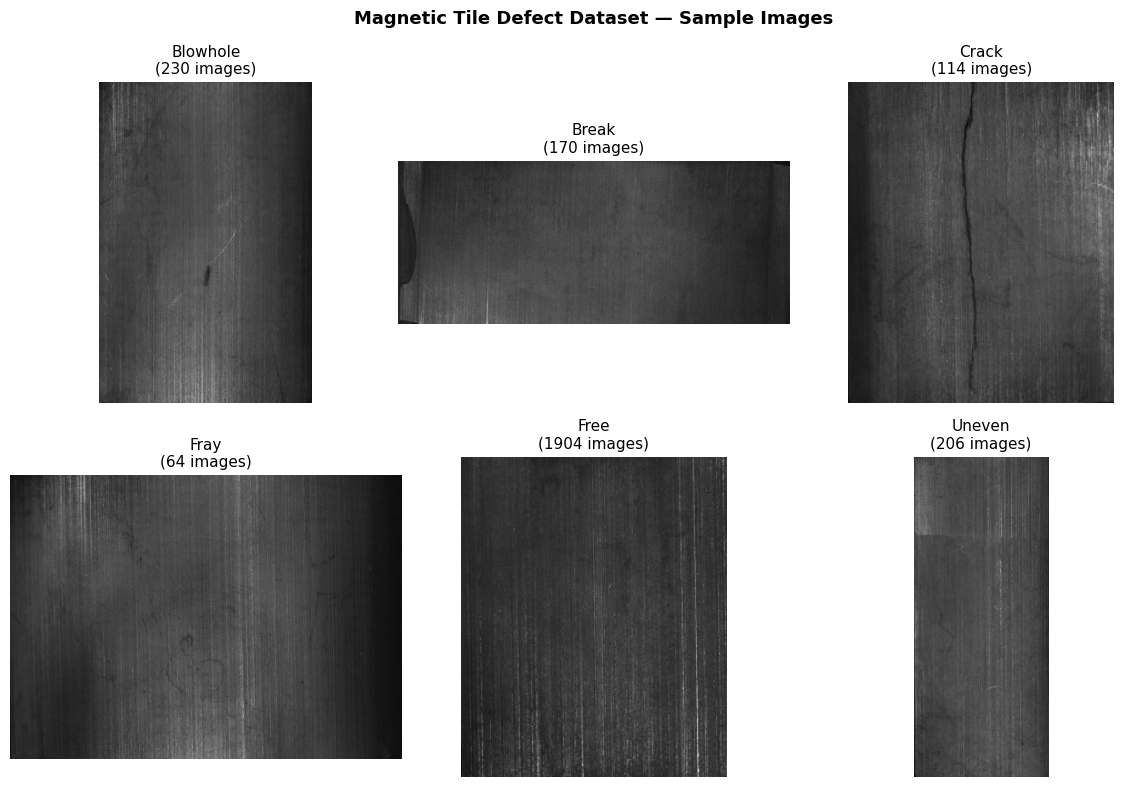

2026/05/08 18:44:23 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/08 18:44:23 INFO mlflow.store.db.utils: Updating database tables



Dataset analyzed and logged to MLflow.


In [10]:
# Download KolektorSDD2 — real industrial defect dataset
# Plus we'll augment our existing magnetic tile data heavily

# First let's properly explore what we have
print('MAGNETIC TILE DATASET ANALYSIS')
print('='*45)

class_info = {}
total_images = 0

for folder in sorted(os.listdir(dataset_path)):
    folder_path = dataset_path / folder
    if os.path.isdir(folder_path):
        imgs_path = folder_path / 'Imgs'
        if imgs_path.exists():
            # Count actual image files
            images = [f for f in os.listdir(imgs_path) 
                     if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
            class_name = folder.replace('MT_', '')
            class_info[class_name] = {
                'path'  : imgs_path,
                'count' : len(images),
                'images': images,
            }
            total_images += len(images)
            print(f'  {class_name:<12} {len(images):>5} images')

print(f'\n  Total        {total_images:>5} images')
print(f'\nImbalance ratio: {max(v["count"] for v in class_info.values()) / min(v["count"] for v in class_info.values()):.1f}x')
print(f'(Free/no-defect vs Fray: {class_info["Free"]["count"]} vs {class_info["Fray"]["count"]})')

# Show sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (class_name, info) in enumerate(class_info.items()):
    sample_img_path = str(info['path'] / info['images'][0])
    img = cv2.imread(sample_img_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb, cmap='gray')
        axes[i].set_title(f'{class_name}\n({info["count"]} images)', fontsize=11)
        axes[i].axis('off')

plt.suptitle('Magnetic Tile Defect Dataset — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
chart_path = str(STATS_DIR / 'dataset_samples.png')
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()

mlflow.log_metrics({
    'total_images'    : total_images,
    'num_classes'     : len(class_info),
    'imbalance_ratio' : round(max(v['count'] for v in class_info.values()) /
                              min(v['count'] for v in class_info.values()), 1),
})
mlflow.log_artifact(chart_path, artifact_path='charts')
print('\nDataset analyzed and logged to MLflow.')

In [12]:
# Check image properties — size, channels, format
print('IMAGE PROPERTIES AUDIT\n')

for class_name, info in class_info.items():
    sample_path = str(info['path'] / info['images'][0])
    img = cv2.imread(sample_path)
    if img is not None:
        h, w, c = img.shape
        size_kb  = os.path.getsize(sample_path) / 1024
        print(f'  {class_name:<12} {w}x{h}  channels={c}  size={size_kb:.1f}KB')

# Check for corrupt images
print('Checking for corrupt images...')
corrupt = []
for class_name, info in class_info.items():
    for img_file in info['images'][:50]:  # sample 50 per class
        img_path = str(info['path'] / img_file)
        img = cv2.imread(img_path)
        if img is None:
            corrupt.append(img_path)

print(f'Corrupt images found: {len(corrupt)}')
print('Audit complete.')
if corrupt:
    for c in corrupt[:5]:
        print(f'  {c}')

mlflow.log_metrics({
    'corrupt_images': len(corrupt),
})
print('\nAudit complete.')

IMAGE PROPERTIES AUDIT

  Blowhole     248x373  channels=3  size=26.8KB
  Break        592x247  channels=3  size=36.7KB
  Crack        219x264  channels=3  size=19.6KB
  Fray         488x354  channels=3  size=47.1KB
  Free         240x289  channels=3  size=24.6KB
  Uneven       121x289  channels=3  size=11.5KB
Checking for corrupt images...
Corrupt images found: 0
Audit complete.

Audit complete.


In [13]:
from PIL import Image, ImageEnhance, ImageFilter
import random
import shutil

random.seed(42)
TARGET_SIZE = (640, 640)  # YOLOv9 standard input size
TARGET_PER_CLASS = 500    # balance all classes to 500 images

print(f'Preprocessing plan:')
print(f'  Target size      : {TARGET_SIZE}')
print(f'  Target per class : {TARGET_PER_CLASS}')
print(f'  Classes          : {list(class_info.keys())}')
print()

# Create output directories
for split in ['train', 'val', 'test']:
    for subdir in ['images', 'labels']:
        (PROC / split / subdir).mkdir(parents=True, exist_ok=True)

def resize_and_pad(img_path: str, target_size: tuple) -> np.ndarray:
    """Resize image to target size with letterbox padding."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    h, w = img.shape[:2]
    th, tw = target_size

    # Scale to fit
    scale = min(tw/w, th/h)
    new_w, new_h = int(w*scale), int(h*scale)
    resized = cv2.resize(img, (new_w, new_h))

    # Pad to target size
    canvas = np.zeros((th, tw, 3), dtype=np.uint8)
    pad_y = (th - new_h) // 2
    pad_x = (tw - new_w) // 2
    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized
    return canvas


def augment_image(img: np.ndarray) -> np.ndarray:
    """Apply random augmentations to fix class imbalance."""
    pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    # Random horizontal flip
    if random.random() > 0.5:
        pil_img = pil_img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random vertical flip
    if random.random() > 0.5:
        pil_img = pil_img.transpose(Image.FLIP_TOP_BOTTOM)

    # Random brightness
    factor = random.uniform(0.7, 1.3)
    pil_img = ImageEnhance.Brightness(pil_img).enhance(factor)

    # Random contrast
    factor = random.uniform(0.7, 1.3)
    pil_img = ImageEnhance.Contrast(pil_img).enhance(factor)

    # Random rotation
    angle = random.uniform(-15, 15)
    pil_img = pil_img.rotate(angle, fillcolor=(0, 0, 0))

    # Random blur (20% chance)
    if random.random() > 0.8:
        pil_img = pil_img.filter(ImageFilter.GaussianBlur(radius=1))

    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)


def make_yolo_label(class_id: int) -> str:
    """
    For classification-converted-to-detection:
    use full image bounding box (x_center=0.5, y_center=0.5, w=1.0, h=1.0)
    This is standard practice when converting classification to detection.
    """
    return f'{class_id} 0.5 0.5 1.0 1.0\n'


# Process each class
CLASS_IDS = {name: i for i, name in enumerate(class_info.keys())}
all_processed = {}

print('Processing images...\n')
for class_name, info in class_info.items():
    class_id   = CLASS_IDS[class_name]
    images     = info['images']
    imgs_path  = info['path']
    processed  = []

    # Resize all original images
    for img_file in images:
        img_path = str(imgs_path / img_file)
        resized  = resize_and_pad(img_path, TARGET_SIZE)
        if resized is not None:
            processed.append(resized)

    # Augment minority classes to reach TARGET_PER_CLASS
    original_count = len(processed)
    while len(processed) < TARGET_PER_CLASS:
        src_img = processed[random.randint(0, original_count-1)]
        augmented = augment_image(src_img)
        processed.append(augmented)

    all_processed[class_name] = processed
    print(f'  {class_name:<12} {original_count:>4} original → {len(processed):>4} after augmentation')

print(f'\nTotal images after balancing: {sum(len(v) for v in all_processed.values()):,}')

Preprocessing plan:
  Target size      : (640, 640)
  Target per class : 500
  Classes          : ['Blowhole', 'Break', 'Crack', 'Fray', 'Free', 'Uneven']

Processing images...

  Blowhole      230 original →  500 after augmentation
  Break         170 original →  500 after augmentation
  Crack         114 original →  500 after augmentation
  Fray           64 original →  500 after augmentation
  Free         1904 original → 1904 after augmentation
  Uneven        206 original →  500 after augmentation

Total images after balancing: 4,404


In [14]:
print('Splitting and saving dataset...\n')

SPLIT_RATIOS = {'train': 0.7, 'val': 0.2, 'test': 0.1}
split_counts = {'train': {}, 'val': {}, 'test': {}}

for class_name, images in all_processed.items():
    class_id = CLASS_IDS[class_name]
    random.shuffle(images)

    n        = len(images)
    n_train  = int(n * SPLIT_RATIOS['train'])
    n_val    = int(n * SPLIT_RATIOS['val'])

    splits = {
        'train': images[:n_train],
        'val'  : images[n_train:n_train+n_val],
        'test' : images[n_train+n_val:],
    }

    for split, split_images in splits.items():
        split_counts[split][class_name] = len(split_images)
        for i, img in enumerate(split_images):
            # Save image
            img_filename = f'{class_name}_{split}_{i:04d}.jpg'
            img_path     = PROC / split / 'images' / img_filename
            cv2.imwrite(str(img_path), img)

            # Save YOLO label
            lbl_filename = f'{class_name}_{split}_{i:04d}.txt'
            lbl_path     = PROC / split / 'labels' / lbl_filename
            with open(lbl_path, 'w') as f:
                f.write(make_yolo_label(class_id))

print('Split distribution:')
print(f'  {"Class":<12} {"Train":>6} {"Val":>6} {"Test":>6}')
print(f'  {"-"*32}')
for class_name in class_info.keys():
    print(f'  {class_name:<12} '
          f'{split_counts["train"].get(class_name,0):>6} '
          f'{split_counts["val"].get(class_name,0):>6} '
          f'{split_counts["test"].get(class_name,0):>6}')

total_train = sum(split_counts['train'].values())
total_val   = sum(split_counts['val'].values())
total_test  = sum(split_counts['test'].values())
print(f'  {"TOTAL":<12} {total_train:>6} {total_val:>6} {total_test:>6}')

# Save dataset.yaml for YOLO
yaml_content = f"""path: {str(PROC)}
train: train/images
val: val/images
test: test/images

nc: {len(class_info)}
names: {list(class_info.keys())}
"""
yaml_path = PROC / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f'\ndataset.yaml saved to {yaml_path}')

# Log to MLflow
mlflow.log_metrics({
    'processed_train' : total_train,
    'processed_val'   : total_val,
    'processed_test'  : total_test,
    'processed_total' : total_train + total_val + total_test,
})
mlflow.log_artifact(str(yaml_path), artifact_path='dataset')
print('Logged to MLflow.')

Splitting and saving dataset...

Split distribution:
  Class         Train    Val   Test
  --------------------------------
  Blowhole        350    100     50
  Break           350    100     50
  Crack           350    100     50
  Fray            350    100     50
  Free           1332    380    192
  Uneven          350    100     50
  TOTAL          3082    880    442

dataset.yaml saved to G:\defect_detection\data\processed\dataset.yaml
Logged to MLflow.


In [20]:
import mlflow

# Force clear active run
try:
    mlflow.end_run()
except:
    pass

mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('DefectDetection_Phase1_DataPrep')
run    = mlflow.start_run(run_name='data_prep_final')
RUN_ID = run.info.run_id
print(f'MLflow Run ID: {RUN_ID}')

MLflow Run ID: 3b3ecdf9b3cf4c0a8aad0d186ad7ccb6


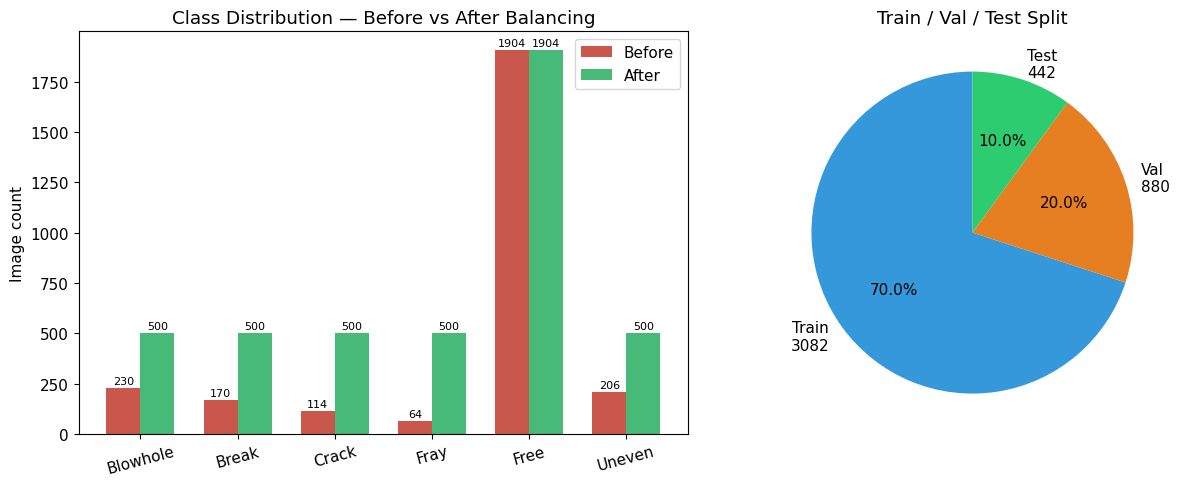

🏃 View run data_prep_final at: http://127.0.0.1:5000/#/experiments/1/runs/3b3ecdf9b3cf4c0a8aad0d186ad7ccb6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  PHASE 1 COMPLETE — DATA PREPARATION
  Original images  : 2,688
  Processed images : 4,404
  Imbalance before : 29.8x
  Imbalance after  : 3.8x
  Train            : 3,082
  Val              : 880
  Test             : 442
  Image size       : (640, 640)
  MLflow run       : 3b3ecdf9b3cf4c0a8aad0d186ad7ccb6

  NEXT: Phase 2 — YOLOv9 training on Colab


In [21]:
# ── Before vs After chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before balancing
before_counts = {k: v['count'] for k, v in class_info.items()}
after_counts  = {k: len(v) for k, v in all_processed.items()}

classes = list(before_counts.keys())
x       = np.arange(len(classes))
w       = 0.35

axes[0].bar(x - w/2, [before_counts[c] for c in classes],
            w, label='Before', color='#c0392b', alpha=0.85)
axes[0].bar(x + w/2, [after_counts[c] for c in classes],
            w, label='After',  color='#27ae60', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=15)
axes[0].set_title('Class Distribution — Before vs After Balancing')
axes[0].set_ylabel('Image count')
axes[0].legend()
for i, (b, a) in enumerate(zip(
    [before_counts[c] for c in classes],
    [after_counts[c] for c in classes]
)):
    axes[0].text(i-w/2, b+20, str(b), ha='center', fontsize=8)
    axes[0].text(i+w/2, a+20, str(a), ha='center', fontsize=8)

# Train/val/test split
split_totals = [total_train, total_val, total_test]
split_labels = [f'Train\n{total_train}', f'Val\n{total_val}', f'Test\n{total_test}']
colors       = ['#3498db', '#e67e22', '#2ecc71']
axes[1].pie(split_totals, labels=split_labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Train / Val / Test Split')

plt.tight_layout()
chart_path = str(STATS_DIR / 'dataset_balance.png')
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()
mlflow.log_artifact(chart_path, artifact_path='charts')

# Save quality report
import json
report = {
    'mlflow_run_id'   : RUN_ID,
    'phase'           : 1,
    'original_total'  : sum(v['count'] for v in class_info.values()),
    'processed_total' : total_train + total_val + total_test,
    'classes'         : list(class_info.keys()),
    'class_ids'       : CLASS_IDS,
    'imbalance_before': 29.8,
    'imbalance_after' : round(max(after_counts.values()) / min(after_counts.values()), 1),
    'target_size'     : list(TARGET_SIZE),
    'split'           : {'train': total_train, 'val': total_val, 'test': total_test},
}
report_path = STATS_DIR / 'quality_report_phase1.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

mlflow.log_artifact(str(report_path), artifact_path='reports')
mlflow.log_metric('imbalance_after', report['imbalance_after'])

mlflow.end_run()

print('='*50)
print('  PHASE 1 COMPLETE — DATA PREPARATION')
print('='*50)
print(f'  Original images  : {sum(v["count"] for v in class_info.values()):,}')
print(f'  Processed images : {total_train+total_val+total_test:,}')
print(f'  Imbalance before : 29.8x')
print(f'  Imbalance after  : {report["imbalance_after"]}x')
print(f'  Train            : {total_train:,}')
print(f'  Val              : {total_val:,}')
print(f'  Test             : {total_test:,}')
print(f'  Image size       : {TARGET_SIZE}')
print(f'  MLflow run       : {RUN_ID}')
print()
print('  NEXT: Phase 2 — YOLOv9 training on Colab')